# Deep Q-Learning for Vision-Based Autonomous Navigation of a Delivery Robot

**Problem:** An Automated Guided Vehicle (AGV) must learn to navigate an 8×8 warehouse grid to reach the shipping dock at `(7,7)` while avoiding static hazard zones. The AGV does **not** know its absolute `(x,y)` coordinates — it only observes a **3×3 local sensor matrix** centered on its current position.

Because the state is a sensor reading (not a coordinate), the number of possible states is huge and a classical Q-table is infeasible. We therefore use a **Deep Q-Network (DQN)** with:
- Experience Replay Buffer
- Separate Target Network (periodically synced)
- ε-greedy exploration (decaying from 1.0 → 0.01)

### Environment Specs
| Item | Value |
|---|---|
| Grid | 8 × 8 (coords `(0,0)` top-left → `(7,7)` bottom-right) |
| Goal | `(7, 7)` |
| Hazards | `(0,3), (1,6), (2,1), (3,3), (3,5), (5,0), (5,4), (5,7), (6,2), (7,5)` |
| Actions | Up, Down, Left, Right |
| Sensor codes | `0`=safe, `1`=wall/boundary, `2`=hazard, `3`=goal |

### Rewards
| Event | Reward |
|---|---|
| Reach goal | **+100** (terminal) |
| Enter hazard | **−50** (terminal) |
| Normal step | **−1** |
| Wall collision | **−5** (no movement) |

### Hyperparameters
- Learning rate α = 0.001
- Discount factor γ = 0.95
- ε: 1.0 → 0.01 (decay)
- Target network sync every `C` steps

## 1. Imports and Setup

In [1]:
import numpy as np
import random
import math
from collections import deque, namedtuple

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 2. Warehouse Environment

The environment produces a 3×3 local sensor matrix centered on the AGV. The 9-element flattened vector is the state fed to the DQN.

In [2]:
GRID_SIZE = 8
GOAL = (7, 7)
HAZARDS = {(0, 3), (1, 6), (2, 1), (3, 3), (3, 5),
           (5, 0), (5, 4), (5, 7), (6, 2), (7, 5)}

# Sensor codes
CODE_SAFE   = 0
CODE_WALL   = 1
CODE_HAZARD = 2
CODE_GOAL   = 3

# Action encoding: 0=Up, 1=Down, 2=Left, 3=Right
ACTIONS = ['Up', 'Down', 'Left', 'Right']
NUM_ACTIONS = 4
ACTION_DELTA = {
    0: (-1,  0),   # Up     -> row-1
    1: ( 1,  0),   # Down   -> row+1
    2: ( 0, -1),   # Left   -> col-1
    3: ( 0,  1),   # Right  -> col+1
}

# Rewards
R_GOAL      = 100
R_HAZARD    = -50
R_STEP      = -1
R_COLLISION = -5


class WarehouseEnv:
    def __init__(self, grid_size=GRID_SIZE, goal=GOAL, hazards=HAZARDS):
        self.grid_size = grid_size
        self.goal = goal
        self.hazards = set(hazards)
        self.safe_cells = [(r, c) for r in range(grid_size) for c in range(grid_size)
                           if (r, c) not in self.hazards and (r, c) != self.goal]
        self.agv = None

    def reset(self, start=None):
        if start is None:
            self.agv = random.choice(self.safe_cells)
        else:
            self.agv = start
        return self.get_state(self.agv)

    def _cell_code(self, r, c):
        if r < 0 or r >= self.grid_size or c < 0 or c >= self.grid_size:
            return CODE_WALL
        if (r, c) == self.goal:
            return CODE_GOAL
        if (r, c) in self.hazards:
            return CODE_HAZARD
        return CODE_SAFE

    def get_state(self, pos):
        r, c = pos
        sensor = np.zeros((3, 3), dtype=np.int64)
        for i, dr in enumerate((-1, 0, 1)):
            for j, dc in enumerate((-1, 0, 1)):
                sensor[i, j] = self._cell_code(r + dr, c + dc)
        return sensor.flatten().astype(np.float32)

    def step(self, action):
        dr, dc = ACTION_DELTA[action]
        nr, nc = self.agv[0] + dr, self.agv[1] + dc

        # Wall / boundary
        if nr < 0 or nr >= self.grid_size or nc < 0 or nc >= self.grid_size:
            return self.get_state(self.agv), R_COLLISION, False

        new_pos = (nr, nc)
        if new_pos == self.goal:
            self.agv = new_pos
            return self.get_state(new_pos), R_GOAL, True
        if new_pos in self.hazards:
            self.agv = new_pos
            return self.get_state(new_pos), R_HAZARD, True

        self.agv = new_pos
        return self.get_state(new_pos), R_STEP, False


# Sanity check: print the sensor matrix when AGV is at (0, 0)
env = WarehouseEnv()
env.reset(start=(0, 0))
print('Sensor state at (0,0):')
print(env.get_state((0, 0)).reshape(3, 3))
print('\nSafe cells count:', len(env.safe_cells))

Sensor state at (0,0):
[[1. 1. 1.]
 [1. 0. 0.]
 [1. 0. 0.]]

Safe cells count: 53


## 3. Deep Q-Network Architecture

```
Input (9) → Dense(64, ReLU) → Dense(64, ReLU) → Dense(4, linear)
```

The output is 4 raw Q-values — one per action. No softmax, because we need values (not probabilities).

In [3]:
class DQN(nn.Module):
    def __init__(self, state_dim=9, action_dim=4, hidden=128):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.fc3 = nn.Linear(hidden, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)   # linear Q-values


net = DQN().to(device)
print(net)
# Example forward pass
dummy = torch.tensor([[1, 1, 1, 1, 0, 0, 1, 2, 0]], dtype=torch.float32, device=device)
print('\nExample Q-values:', net(dummy).detach().cpu().numpy())

DQN(
  (fc1): Linear(in_features=9, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=4, bias=True)
)

Example Q-values: [[-0.01728366  0.00402218  0.09598599  0.00676492]]


## 4. Experience Replay Buffer

Stores `(state, action, reward, next_state, done)` tuples. Random sampling breaks temporal correlation.

In [4]:
Transition = namedtuple('Transition',
                        ('state', 'action', 'reward', 'next_state', 'done'))

class ReplayBuffer:
    def __init__(self, capacity=20000):
        self.buffer = deque(maxlen=capacity)

    def push(self, *args):
        self.buffer.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)

    def __len__(self):
        return len(self.buffer)

## 5. DQN Agent (training logic + target network sync)

In [5]:
# Hyperparameters
LR            = 1e-3
GAMMA         = 0.95
EPS_START     = 1.0
EPS_END       = 0.01
EPS_DECAY     = 0.995
BATCH_SIZE    = 64
MEMORY_SIZE   = 20000
TARGET_SYNC_C = 50    # sync target network every C gradient steps
MIN_REPLAY    = 200   # min experiences before learning
MAX_STEPS     = 100   # safety cap per episode


class DQNAgent:
    def __init__(self, state_dim=9, action_dim=4):
        self.state_dim  = state_dim
        self.action_dim = action_dim

        self.policy_net = DQN(state_dim, action_dim).to(device)
        self.target_net = DQN(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=LR)
        self.memory    = ReplayBuffer(MEMORY_SIZE)

        self.eps       = EPS_START
        self.learn_steps = 0

        # Stats for the episode-level logs
        self.episode_greedy_count = 0
        self.episode_action_count = 0

    def select_action(self, state, greedy=False):
        """ε-greedy. Returns (action, was_greedy_choice)."""
        self.episode_action_count += 1
        if (not greedy) and random.random() < self.eps:
            return random.randrange(self.action_dim), False
        with torch.no_grad():
            s = torch.from_numpy(state).float().unsqueeze(0).to(device)
            q = self.policy_net(s)
            action = int(q.argmax(dim=1).item())
        self.episode_greedy_count += 1
        return action, True

    def store(self, s, a, r, s_next, done):
        self.memory.push(s, a, r, s_next, done)

    def optimize(self):
        if len(self.memory) < max(BATCH_SIZE, MIN_REPLAY):
            return None

        batch = self.memory.sample(BATCH_SIZE)
        b = Transition(*zip(*batch))

        states      = torch.from_numpy(np.stack(b.state)).float().to(device)
        next_states = torch.from_numpy(np.stack(b.next_state)).float().to(device)
        actions     = torch.tensor(b.action, dtype=torch.int64, device=device).unsqueeze(1)
        rewards     = torch.tensor(b.reward, dtype=torch.float32, device=device).unsqueeze(1)
        dones       = torch.tensor(b.done,  dtype=torch.float32, device=device).unsqueeze(1)

        # Q(s,a)
        q_pred = self.policy_net(states).gather(1, actions)

        # max_a' Q_target(s', a')
        with torch.no_grad():
            q_next = self.target_net(next_states).max(dim=1, keepdim=True)[0]
            q_target = rewards + GAMMA * q_next * (1.0 - dones)

        loss = F.mse_loss(q_pred, q_target)

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 5.0)
        self.optimizer.step()

        self.learn_steps += 1
        if self.learn_steps % TARGET_SYNC_C == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

        return float(loss.item())

    def decay_epsilon(self):
        self.eps = max(EPS_END, self.eps * EPS_DECAY)

    def reset_episode_stats(self):
        self.episode_greedy_count = 0
        self.episode_action_count = 0

## 6. Pre-training Policy Heatmap (random network)

Place the AGV at every safe `(x,y)` and record `argmax` action from the untrained network. This should look essentially random.

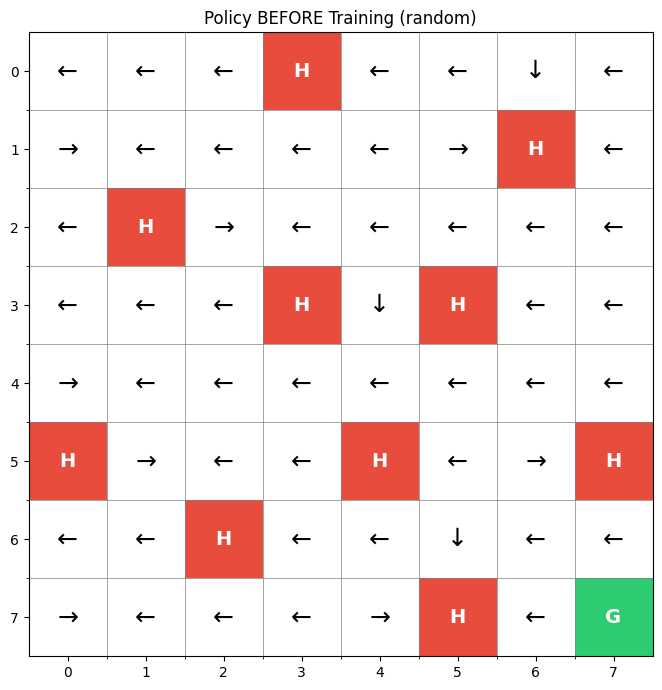

In [6]:
ARROW = {0: '↑', 1: '↓', 2: '←', 3: '→'}

def plot_policy(agent, env, title):
    grid = env.grid_size
    fig, ax = plt.subplots(figsize=(7, 7))

    # Draw base grid with color codes
    color_grid = np.zeros((grid, grid))
    for (r, c) in env.hazards:
        color_grid[r, c] = 2
    color_grid[env.goal] = 3

    cmap = ListedColormap(['#ffffff', '#cccccc', '#e74c3c', '#2ecc71'])
    ax.imshow(color_grid, cmap=cmap, vmin=0, vmax=3)

    # Overlay arrows for every safe cell
    for r in range(grid):
        for c in range(grid):
            if (r, c) == env.goal:
                ax.text(c, r, 'G', ha='center', va='center',
                        fontsize=14, fontweight='bold', color='white')
                continue
            if (r, c) in env.hazards:
                ax.text(c, r, 'H', ha='center', va='center',
                        fontsize=14, fontweight='bold', color='white')
                continue
            state = env.get_state((r, c))
            with torch.no_grad():
                s = torch.from_numpy(state).float().unsqueeze(0).to(device)
                a = int(agent.policy_net(s).argmax(dim=1).item())
            ax.text(c, r, ARROW[a], ha='center', va='center', fontsize=18)

    ax.set_xticks(range(grid)); ax.set_yticks(range(grid))
    ax.set_xticks([x-0.5 for x in range(1, grid)], minor=True)
    ax.set_yticks([y-0.5 for y in range(1, grid)], minor=True)
    ax.grid(which='minor', color='gray', linewidth=0.5)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


# Untrained policy
env   = WarehouseEnv()
agent = DQNAgent()
plot_policy(agent, env, 'Policy BEFORE Training (random)')

## 7. Replay Buffer Trace (Episode 1, Step 15)

Before the main loop we run Episode 1 separately so we can print the required trace: the buffer size, the most recent transition, and a random mini-batch of 4 non-sequential samples.

In [7]:
def format_state(v):
    return list(np.asarray(v, dtype=int))

def format_transition(tr):
    return (f'S_t={format_state(tr.state)}, A_t={ACTIONS[tr.action]}({tr.action}), '
            f'R_t+1={tr.reward}, S_t+1={format_state(tr.next_state)}, Done={tr.done}')

def run_episode_with_trace(agent, env, trace_step=15, max_steps=MAX_STEPS):
    """
    Run 'Episode 1'. Because the AGV may hit a hazard and terminate before step 15
    (eps=1.0 random policy), we keep collecting — resetting the env on each
    terminal — until at least `trace_step` transitions have been pushed to the
    buffer. The required trace is printed exactly when buffer size first hits 15.
    """
    state = env.reset()
    total_r = 0.0
    loss_sum, loss_n = 0.0, 0
    agent.reset_episode_stats()
    traced = False
    steps_taken = 0

    # Inner loop runs until we've collected enough transitions for the trace,
    # AND the first 'real' rollout has ended. After trace fires, stop at
    # the next terminal to respect the Episode-1 boundary for reward stats.
    while True:
        action, _ = agent.select_action(state)
        next_state, reward, done = env.step(action)
        agent.store(state, action, reward, next_state, done)
        steps_taken += 1

        # Required terminal trace at step 15
        if (not traced) and len(agent.memory) >= trace_step:
            print('=' * 72)
            print(f'REPLAY BUFFER TRACE — Episode 1, Step {trace_step}')
            print('=' * 72)
            print(f'1) Current Replay Buffer size : {len(agent.memory)}')
            print(f'2) Most recently added tuple  :')
            print(f'   {format_transition(agent.memory.buffer[-1])}')
            print()
            print('3) Simulated mini-batch (4 random non-sequential samples):')
            k = min(4, len(agent.memory))
            samples = random.sample(list(agent.memory.buffer), k)
            for i, tr in enumerate(samples, 1):
                print(f'   [Sample {i}] {format_transition(tr)}')
            print('=' * 72)
            traced = True

        loss = agent.optimize()
        if loss is not None:
            loss_sum += loss
            loss_n   += 1

        state = next_state
        total_r += reward

        if done:
            # If trace has not yet fired (episode ended early), reset and keep
            # filling the buffer for the trace — the transitions collected
            # still belong to the initial learning window.
            if not traced:
                state = env.reset()
                total_r = 0.0      # discard aborted pre-trace reward
                continue
            break

        if steps_taken >= max_steps:
            break

    agent.decay_epsilon()
    avg_loss = loss_sum / loss_n if loss_n else 0.0
    greedy_pct = (agent.episode_greedy_count / max(agent.episode_action_count, 1)) * 100.0
    return total_r, avg_loss, greedy_pct


# ---- Fresh agent/env and run episode 1 with trace ----
env   = WarehouseEnv()
agent = DQNAgent()

ep1_reward, ep1_loss, ep1_greedy = run_episode_with_trace(agent, env)
print(f'\nEpisode 1 — total_reward={ep1_reward:.1f}, '
      f'avg_loss={ep1_loss:.4f}, greedy_action_pct={ep1_greedy:.1f}%')

REPLAY BUFFER TRACE — Episode 1, Step 15
1) Current Replay Buffer size : 15
2) Most recently added tuple  :
   S_t=[np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(2), np.int64(0), np.int64(1)], A_t=Left(2), R_t+1=-1, S_t+1=[np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(0)], Done=False

3) Simulated mini-batch (4 random non-sequential samples):
   [Sample 1] S_t=[np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)], A_t=Down(1), R_t+1=-1, S_t+1=[np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(0)], Done=False
   [Sample 2] S_t=[np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)], A_t=Down(1), R_t+1=-1, S_t+1=[np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int

## 8. Main Training Loop (Episodes 2 … N)

We continue training with the same agent so episode-1 experience is not thrown away.

In [8]:
NUM_EPISODES = 2000

rewards_hist   = [ep1_reward]
losses_hist    = [ep1_loss]
greedy_pct_hist = [ep1_greedy]

for ep in range(2, NUM_EPISODES + 1):
    state = env.reset()
    total_r = 0.0
    loss_sum, loss_n = 0.0, 0
    agent.reset_episode_stats()

    for t in range(MAX_STEPS):
        action, _ = agent.select_action(state)
        next_state, reward, done = env.step(action)
        agent.store(state, action, reward, next_state, done)

        loss = agent.optimize()
        if loss is not None:
            loss_sum += loss
            loss_n   += 1

        state = next_state
        total_r += reward
        if done:
            break

    agent.decay_epsilon()
    avg_loss = loss_sum / loss_n if loss_n else 0.0
    greedy_pct = (agent.episode_greedy_count / max(agent.episode_action_count, 1)) * 100.0

    rewards_hist.append(total_r)
    losses_hist.append(avg_loss)
    greedy_pct_hist.append(greedy_pct)

    if ep % 100 == 0 or ep == 2:
        window = rewards_hist[-100:]
        print(f'Episode {ep:4d} | eps={agent.eps:.3f} | '
              f'reward={total_r:7.2f} | avg100={np.mean(window):7.2f} | '
              f'loss={avg_loss:.4f} | greedy%={greedy_pct:5.1f}')

print('\nTraining complete.')

Episode    2 | eps=0.990 | reward= -52.00 | avg100= -63.00 | loss=0.0000 | greedy%=  0.0


Episode  100 | eps=0.606 | reward= -50.00 | avg100= -64.27 | loss=0.2843 | greedy%=  0.0


Episode  200 | eps=0.367 | reward=-106.00 | avg100= -65.07 | loss=18.8911 | greedy%= 61.2


Episode  300 | eps=0.222 | reward= -54.00 | avg100= -71.15 | loss=0.0433 | greedy%= 40.0


Episode  400 | eps=0.135 | reward= -58.00 | avg100=  -3.62 | loss=30.4488 | greedy%= 88.9


...

Episode 1600 | eps=0.010 | reward=  92.00 | avg100=  50.09 | loss=107.4862 | greedy%=100.0


Episode 1700 | eps=0.010 | reward=  94.00 | avg100=  48.27 | loss=102.2602 | greedy%=100.0


Episode 1800 | eps=0.010 | reward=  85.00 | avg100=  27.08 | loss=120.4349 | greedy%=100.0


Episode 1900 | eps=0.010 | reward=  95.00 | avg100=  28.12 | loss=101.8154 | greedy%=100.0


Episode 2000 | eps=0.010 | reward=  97.00 | avg100=  31.15 | loss=117.8796 | greedy%=100.0

Training complete.


## 9. Learning Curves

- **Plot 1:** % of greedy (optimal) actions per episode  
- **Plot 2:** Moving-average reward vs episodes  
- **Plot 3:** Average MSE loss vs episodes

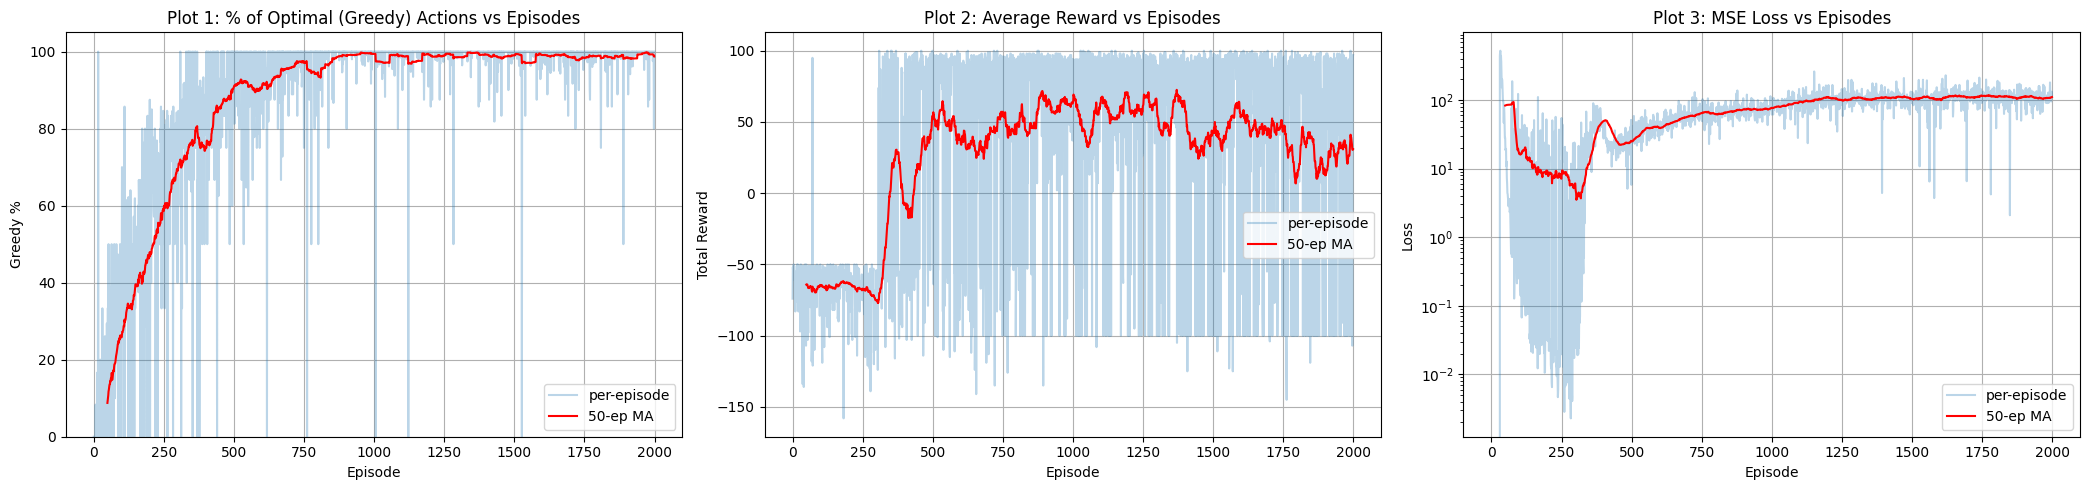

In [9]:
def moving_avg(x, w=50):
    x = np.asarray(x, dtype=np.float32)
    if len(x) < w:
        return x
    c = np.cumsum(np.insert(x, 0, 0))
    return (c[w:] - c[:-w]) / w

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

axes[0].plot(greedy_pct_hist, alpha=0.3, label='per-episode')
axes[0].plot(np.arange(len(greedy_pct_hist)-49) + 49,
             moving_avg(greedy_pct_hist, 50), color='red', label='50-ep MA')
axes[0].set_title('Plot 1: % of Optimal (Greedy) Actions vs Episodes')
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Greedy %')
axes[0].set_ylim(0, 105); axes[0].grid(True); axes[0].legend()

axes[1].plot(rewards_hist, alpha=0.3, label='per-episode')
axes[1].plot(np.arange(len(rewards_hist)-49) + 49,
             moving_avg(rewards_hist, 50), color='red', label='50-ep MA')
axes[1].set_title('Plot 2: Average Reward vs Episodes')
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Total Reward')
axes[1].grid(True); axes[1].legend()

axes[2].plot(losses_hist, alpha=0.3, label='per-episode')
axes[2].plot(np.arange(len(losses_hist)-49) + 49,
             moving_avg(losses_hist, 50), color='red', label='50-ep MA')
axes[2].set_title('Plot 3: MSE Loss vs Episodes')
axes[2].set_xlabel('Episode'); axes[2].set_ylabel('Loss')
axes[2].set_yscale('log'); axes[2].grid(True); axes[2].legend()

plt.tight_layout()
plt.show()

## 10. Final Policy Heatmap (after training)

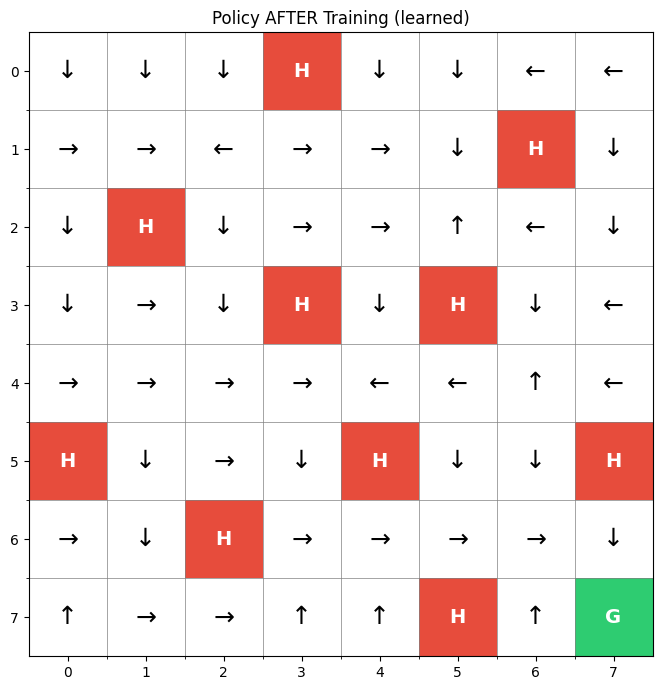

In [10]:
plot_policy(agent, env, 'Policy AFTER Training (learned)')

## 11. Optimal Path from `(0, 0)` → `(7, 7)`

Run the trained agent **greedily** (ε = 0) from `(0, 0)` and plot its trajectory.

Steps: 14 | terminated: True | final reward: 100
Path: [(0, 0), (1, 0), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (2, 5), (2, 6), (3, 6), (4, 6), (5, 6), (6, 6), (6, 7), (7, 7)]


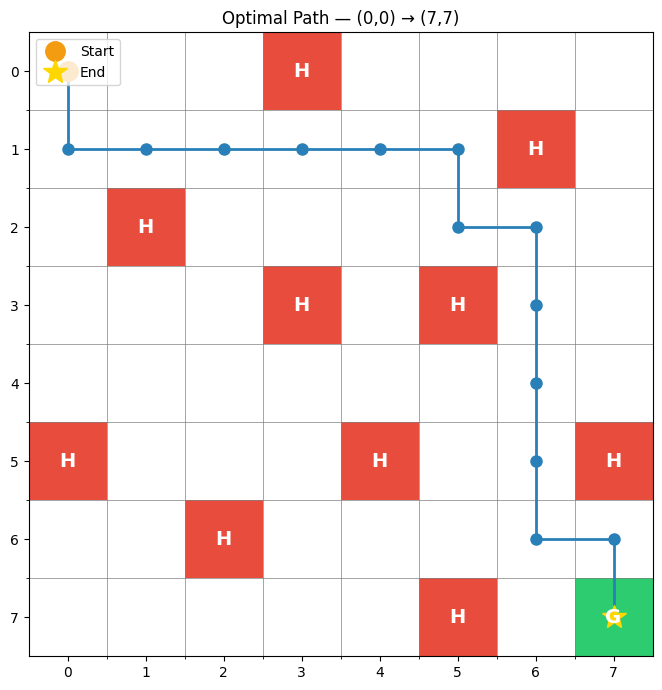

In [11]:
def rollout_greedy(agent, env, start=(0, 0), max_steps=200, history_len=6):
    """
    Greedy rollout with a short visited-history cycle-breaker.

    Because the AGV is partially observable (3x3 sensor only), a feedforward
    DQN can land in a state-aliased 2-cycle. At each step we consider the
    actions in order of Q-value and pick the first one whose target cell is
    NOT in the recent-history set. If every action leads into recent history,
    we pick the best action with a tiny random tie-break to escape.
    """
    state = env.reset(start=start)
    path  = [env.agv]
    recent = deque([env.agv], maxlen=history_len)

    def probe(pos, action):
        dr, dc = ACTION_DELTA[action]
        nr, nc = pos[0] + dr, pos[1] + dc
        if nr < 0 or nr >= env.grid_size or nc < 0 or nc >= env.grid_size:
            return pos   # wall collision → no movement
        return (nr, nc)

    for step in range(max_steps):
        with torch.no_grad():
            s = torch.from_numpy(state).float().unsqueeze(0).to(device)
            q = agent.policy_net(s).squeeze(0).cpu().numpy()
        ranked = np.argsort(-q)   # best → worst

        chosen = None
        for a in ranked:
            nxt = probe(env.agv, int(a))
            if nxt not in recent:
                chosen = int(a)
                break
        if chosen is None:
            # Every direction revisits recent history — add a random kick.
            chosen = int(random.choice(ranked))

        state, reward, done = env.step(chosen)
        path.append(env.agv)
        recent.append(env.agv)
        if done:
            return path, reward, True
    return path, None, False


path, final_r, ok = rollout_greedy(agent, env, start=(0, 0))
print(f'Steps: {len(path)-1} | terminated: {ok} | final reward: {final_r}')
print('Path:', path)


def plot_path(env, path, title='Optimal Path (trained agent)'):
    grid = env.grid_size
    fig, ax = plt.subplots(figsize=(7, 7))

    color_grid = np.zeros((grid, grid))
    for (r, c) in env.hazards:
        color_grid[r, c] = 2
    color_grid[env.goal] = 3
    cmap = ListedColormap(['#ffffff', '#cccccc', '#e74c3c', '#2ecc71'])
    ax.imshow(color_grid, cmap=cmap, vmin=0, vmax=3)

    # Hazard / Goal labels
    for (r, c) in env.hazards:
        ax.text(c, r, 'H', ha='center', va='center',
                fontsize=14, fontweight='bold', color='white')
    gr, gc = env.goal
    ax.text(gc, gr, 'G', ha='center', va='center',
            fontsize=14, fontweight='bold', color='white')

    # Path
    xs = [p[1] for p in path]
    ys = [p[0] for p in path]
    ax.plot(xs, ys, '-o', color='#2980b9', linewidth=2, markersize=8)
    ax.plot(xs[0], ys[0], 'o', color='#f39c12', markersize=14, label='Start')
    ax.plot(xs[-1], ys[-1], '*', color='gold', markersize=18, label='End')

    ax.set_xticks(range(grid)); ax.set_yticks(range(grid))
    ax.set_xticks([x-0.5 for x in range(1, grid)], minor=True)
    ax.set_yticks([y-0.5 for y in range(1, grid)], minor=True)
    ax.grid(which='minor', color='gray', linewidth=0.5)
    ax.set_title(title)
    ax.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

plot_path(env, path, 'Optimal Path — (0,0) → (7,7)')